# 03. 구조화된 출력 (Structured Output)

> JSON을 텍스트로 받아 파싱하는 시대는 지났어요. ProviderStrategy vs ToolStrategy, Union 다중 응답, `handle_errors` — V1 구조화 출력 옵션을 정리해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. ProviderStrategy와 ToolStrategy의 차이를 설명하고 적절히 선택할 수 있어요
2. Pydantic, dataclass, TypedDict 세 가지 스키마 방식으로 구조화된 출력을 정의할 수 있어요
3. Union 타입을 사용해 다중 응답 유형을 하나의 에이전트로 처리할 수 있어요
4. handle_errors 옵션으로 검증 오류를 자동 복구하도록 설정할 수 있어요

## 사전 지식

- `02-Tools-V1.ipynb` — V1 Tool 정의와 create_agent 기본 사용법
- Pydantic BaseModel 기초 (타입 힌트, Field)
- Python 타입 힌트 (Literal, Union, TypedDict)

## 구조화된 출력이란?

에이전트가 자연어 대신 **예측 가능한 데이터 구조**로 응답하게 만드는 기능이에요.
JSON 파싱, 정규식 없이도 앱이 바로 사용할 수 있는 객체를 얻을 수 있어요.

> **왜 구조화된 출력이 필요할까요?** 자연어 응답은 사람에게는 좋지만 코드에서 처리하기 어려워요. "평점은 4.5점입니다"라는 텍스트에서 숫자를 뽑아내려면 파싱이 필요하죠. 구조화된 출력은 **자판기**처럼 동작해요 -- 버튼(스키마)을 누르면 정해진 형태(Pydantic 인스턴스)의 결과가 나와요.

```mermaid
flowchart TD
    A["사용자 입력<br/>자연어 텍스트"] --> B["에이전트<br/>create_agent"]
    B --> C{"전략 선택<br/>Strategy"}
    C -->|"네이티브 지원 모델<br/>OpenAI / Anthropic"| D["ProviderStrategy<br/>모델 API 직접 지원"]
    C -->|"범용 모델<br/>Tool Calling 지원"| E["ToolStrategy<br/>도구 호출 기반"]
    C -->|"스키마만 전달<br/>자동 선택"| F["Auto Selection<br/>최적 전략 자동"]
    D --> G["structured_response<br/>반환"]
    E --> G
    F --> G
    G --> H["Pydantic 인스턴스<br/>/ dataclass / dict"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef strategy fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A input
    class B,F process
    class G,H output
    class D,E strategy
```

### 두 가지 전략 비교

| 전략 | 작동 방식 | 지원 모델 | 권장 상황 |
|------|-----------|-----------|----------|
| **ProviderStrategy** | 모델 API가 JSON Schema를 직접 강제 | OpenAI, Anthropic, Grok 등 | 신뢰성 최우선 |
| **ToolStrategy** | 도구 호출(Tool Calling)을 통해 구조화 | Tool Calling 지원 모든 모델 | 범용성 최우선 |
| **Auto (스키마만 전달)** | 모델 능력에 따라 자동 선택 | -- | 대부분의 상황 |

> 🔑 **핵심 개념**: `response_format`에 스키마 클래스를 직접 전달하면 LangChain이 자동으로 최적 전략을 선택해요.  
> 결과는 항상 에이전트 상태의 **`structured_response`** 키로 반환돼요.

### 스키마 정의 방법 비교

| 방법 | 특징 | 반환 타입 | 적합한 상황 |
|------|------|-----------|------------|
| **Pydantic** | 풍부한 검증 (ge/le, Literal, validator) | Pydantic 인스턴스 | 복잡한 검증이 필요할 때 |
| **dataclass** | 경량, 표준 라이브러리, 추가 의존성 없음 | dataclass 인스턴스 | 단순 구조, 가벼운 사용 |
| **TypedDict** | 딕셔너리로 반환, JSON 직렬화 용이 | 딕셔너리 | API 응답, DB 저장 |

> 💡 **실무 팁**: 대부분의 경우 Pydantic을 권장해요. Field의 `description`이 모델이 각 필드를 정확히 채우는 데 결정적인 역할을 해요.

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 OPENAI_API_KEY 등을 읽어요)
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# LangSmith 추적 설정 (선택 사항)
# 구조화된 출력의 재시도 과정을 시각적으로 확인할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-05-Structured-Output"

## 1. Provider Strategy — 네이티브 구조화 출력

OpenAI, Anthropic 같은 모델은 API 수준에서 JSON Schema를 직접 강제할 수 있어요.
이 방식이 가장 신뢰성이 높아요 — 모델이 스키마를 **반드시** 따르도록 하드웨어 수준에서 제어해요.

`response_format=스키마클래스`로 전달하면 LangChain이 자동으로 ProviderStrategy를 선택해요.

> 🎯 **강의 포인트**: 결과는 `result["messages"]`가 아니라 `result["structured_response"]`에 있어요.  
> 이 점을 강조해서 학생들이 처음부터 올바른 키를 사용하도록 안내하세요.

> ⚠️ **자주 하는 실수**: `result["messages"][-1].content`에서 응답을 찾으려고 해요. 구조화된 출력은 별도의 `structured_response` 키에 있어요.

### 1-1. Pydantic 모델로 연락처 추출

In [3]:
# ---------------------------------------------------
# Pydantic으로 연락처 정보 추출
# ---------------------------------------------------
# Pydantic: 풍부한 검증 기능 (description, ge/le, Literal 등)
# Field의 description이 모델이 각 필드를 이해하는 핵심 단서예요
from pydantic import BaseModel, Field

# V1 API: init_chat_model로 모델 초기화
from langchain.chat_models import init_chat_model

# V1 API: create_agent (create_react_agent는 deprecated)
from langchain.agents import create_agent


class ContactInfo(BaseModel):
    """연락처 정보를 추출하기 위한 스키마예요."""

    name: str = Field(description="The name of the person")  # 이름
    email: str = Field(description="The email address of the person")  # 이메일
    phone: str = Field(description="The phone number of the person")  # 전화번호


# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# Anthropic 사용 시: "anthropic:claude-sonnet-4-5"
model = init_chat_model("openai:gpt-4o-mini")

# response_format에 스키마 클래스를 전달하면 자동으로 ProviderStrategy 선택
agent = create_agent(
    model=model,
    tools=[],
    response_format=ContactInfo,  # 스키마 클래스 직접 전달 → 자동 선택
)

# 에이전트 실행
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567",
            }
        ]
    }
)

# 구조화된 응답은 structured_response 키에 있어요
print(type(result["structured_response"]))  # <class 'ContactInfo'> — Pydantic 인스턴스
print(result["structured_response"])

<class '__main__.ContactInfo'>
name='John Doe' email='john@example.com' phone='(555) 123-4567'


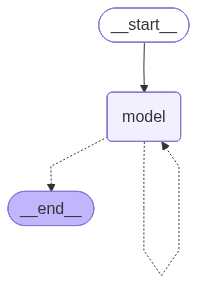

In [4]:
# 그래프 흐름: START → model → {structured_output} → END
# model 노드: LLM이 입력을 분석하고 ContactInfo 스키마에 맞게 구조화된 응답을 생성해요
# response_format에 따라 ProviderStrategy 또는 ToolStrategy가 자동 선택돼요
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### 1-2. dataclass — 경량 스키마

In [5]:
# ---------------------------------------------------
# dataclass로 연락처 정보 추출
# ---------------------------------------------------
# dataclass: Python 표준 라이브러리, 추가 의존성 없음
# 필드 설명은 인라인 주석(comment)으로 제공해요
from dataclasses import dataclass


@dataclass
class ContactInfoDC:
    """연락처 정보 스키마 (dataclass 버전)예요."""

    name: str  # 이름 (The name of the person)
    email: str  # 이메일 주소 (The email address of the person)
    phone: str  # 전화번호 (The phone number of the person)


# dataclass도 response_format에 그대로 전달할 수 있어요
agent_dc = create_agent(
    model=model,
    tools=[],
    response_format=ContactInfoDC,
)

result_dc = agent_dc.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Extract contact info from: Jane Smith, jane@example.com, (555) 987-6543",
            }
        ]
    }
)

print(type(result_dc["structured_response"]))  # <class 'ContactInfoDC'> — dataclass 인스턴스
print(result_dc["structured_response"])

<class '__main__.ContactInfoDC'>
ContactInfoDC(name='Jane Smith', email='jane@example.com', phone='(555) 987-6543')


### 1-3. TypedDict — 딕셔너리 형태 반환

In [6]:
# ---------------------------------------------------
# TypedDict로 연락처 정보 추출
# ---------------------------------------------------
# TypedDict: 반환값이 Python dict → JSON 직렬화 즉시 가능
# API 응답이나 DB 저장에 바로 활용할 수 있어요
from typing_extensions import TypedDict


class ContactInfoTD(TypedDict):
    """연락처 정보 스키마 (TypedDict 버전)예요."""

    name: str  # 이름 (The name of the person)
    email: str  # 이메일 주소 (The email address of the person)
    phone: str  # 전화번호 (The phone number of the person)


agent_td = create_agent(
    model=model,
    tools=[],
    response_format=ContactInfoTD,
)

result_td = agent_td.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Extract contact info from: Gildong Hong, gildong@example.com, (010) 1234-5678",
            }
        ]
    }
)

print(type(result_td["structured_response"]))  # <class 'dict'> — 딕셔너리!
print(result_td["structured_response"])

# JSON 직렬화 바로 가능해요
import json

print("JSON:", json.dumps(result_td["structured_response"], ensure_ascii=False))

<class 'dict'>
{'name': 'Gildong Hong', 'email': 'gildong@example.com', 'phone': '(010) 1234-5678'}
JSON: {"name": "Gildong Hong", "email": "gildong@example.com", "phone": "(010) 1234-5678"}


## 2. Tool Strategy — 도구 호출 기반 구조화 출력

ToolStrategy는 도구 호출(Tool Calling)을 통해 구조화된 출력을 얻어요.
**네이티브 지원 여부와 관계없이** Tool Calling을 지원하는 모든 모델에서 동작하므로 범용성이 높아요.

`ToolStrategy`를 명시적으로 import해서 전달하면 강제로 이 전략을 사용해요.

> 🔑 **핵심 개념**: `ToolStrategy`는 내부적으로 스키마를 "도구"로 등록하고, 모델이 그 도구를 호출하게 만들어요.  
> 그래서 Tool Calling을 지원하는 모든 모델에서 동작해요.

> 🎯 **강의 포인트**: `Literal` 타입으로 허용값을 제한하고 `ge/le`로 수치 범위를 지정하면, 모델이 스키마를 훨씬 정확히 따라요. 직접 예를 들어서 비교해 보세요.

### 2-1. ToolStrategy로 리뷰 분석

In [7]:
# ---------------------------------------------------
# ToolStrategy로 제품 리뷰 분석
# ---------------------------------------------------
# ToolStrategy: 명시적으로 도구 호출 방식 사용
# Literal: 허용값을 제한하면 모델이 더 정확하게 채워요
# ge/le: 수치 범위를 강제할 수 있어요
from pydantic import BaseModel, Field
from typing import Literal

# ToolStrategy를 명시적으로 import해요
from langchain.agents.structured_output import ToolStrategy


class ProductReview(BaseModel):
    """제품 리뷰 분석 스키마예요."""

    rating: int | None = Field(
        description="The rating of the product", ge=1, le=5  # 1~5 범위 강제
    )  # 평점
    sentiment: Literal["positive", "negative"] = Field(
        description="The sentiment of the review"  # positive 또는 negative만 허용
    )  # 감정
    key_points: list[str] = Field(
        description="Key points of the review. Lowercase, 1-3 words each."
    )  # 핵심 포인트


# response_format에 ToolStrategy(스키마) 형태로 전달해요
agent_tool = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(ProductReview),  # 명시적으로 ToolStrategy 사용
)

result = agent_tool.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'",
            }
        ]
    }
)

structured = result["structured_response"]
print(structured)
print(f"\n평점: {structured.rating}")
print(f"감정: {structured.sentiment}")
print(f"핵심: {structured.key_points}")

rating=5 sentiment='positive' key_points=['great product', 'fast shipping']

평점: 5
감정: positive
핵심: ['great product', 'fast shipping']


### 2-2. Union 타입 — 여러 스키마 자동 선택

`Union[SchemaA, SchemaB]`를 사용하면 하나의 에이전트가 여러 종류의 입력을 처리할 수 있어요.
모델이 입력 내용을 보고 **어떤 스키마를 사용할지 자동으로 결정**해요.

> 💡 **실무 팁**: 고객 피드백 처리 시스템처럼 "일반 리뷰"와 "불만 사항"을 구분해서 서로 다른 후속 처리를 해야 할 때 아주 유용해요.

In [8]:
# ---------------------------------------------------
# Union 타입: 입력에 따라 스키마를 자동 선택
# ---------------------------------------------------
# 두 가지 스키마를 준비해요:
# - ProductReview: 일반 리뷰 분석
# - CustomerComplaint: 불만 사항 처리
from typing import Union


class CustomerComplaint(BaseModel):
    """고객 불만 처리 스키마예요."""

    issue_type: Literal["product", "service", "shipping", "billing"] = Field(
        description="The type of issue"
    )  # 문제 유형
    severity: Literal["low", "medium", "high"] = Field(
        description="The severity of the complaint"
    )  # 심각도
    description: str = Field(
        description="Brief description of the complaint"
    )  # 불만 내용


# Union 타입: 모델이 자동으로 맞는 스키마를 선택해요
agent_union = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(Union[ProductReview, CustomerComplaint]),
)

# 일반 리뷰 → ProductReview 선택
result_review = agent_union.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Analyze: 'Great product! 5 stars. Fast shipping but a bit expensive.'",
            }
        ]
    }
)
# [리뷰 입력]
print(f"선택된 스키마: {type(result_review['structured_response']).__name__}")
print(result_review["structured_response"])

print()

# 불만 사항 → CustomerComplaint 선택
result_complaint = agent_union.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Customer complaint: Package arrived damaged and contents were broken.",
            }
        ]
    }
)
# [불만 사항 입력]
print(f"선택된 스키마: {type(result_complaint['structured_response']).__name__}")
print(result_complaint["structured_response"])

선택된 스키마: ProductReview
rating=5 sentiment='positive' key_points=['great product', 'fast shipping', 'expensive']

선택된 스키마: CustomerComplaint
issue_type='shipping' severity='high' description='Package arrived damaged and contents were broken.'


### 2-3. tool_message_content — 대화 기록 커스터마이징

In [9]:
# ---------------------------------------------------
# tool_message_content: 대화 히스토리에 남길 메시지 설정
# ---------------------------------------------------
# 기본값: 도구 호출 결과가 JSON 형태로 기록돼요
# 커스텀 메시지: 사람이 읽기 쉬운 형태로 변경할 수 있어요
# 챗봇 인터페이스에서 사용자에게 처리 상태를 알려줄 때 유용해요
from pydantic import BaseModel, Field
from typing import Literal


class MeetingAction(BaseModel):
    """회의 액션 아이템 추출 스키마예요."""

    task: str = Field(description="The specific task to be completed")  # 작업 내용
    assignee: str = Field(description="Person responsible for the task")  # 담당자
    priority: Literal["low", "medium", "high"] = Field(
        description="Priority level"
    )  # 우선순위


agent_msg = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(
        schema=MeetingAction,
        # 이 메시지가 대화 히스토리의 ToolMessage에 저장돼요
        tool_message_content="액션 아이템이 회의록에 등록되었어요!",
    ),
)

result = agent_msg.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "From our meeting: 민준 needs to update the project timeline ASAP.",
            }
        ]
    }
)

# === 구조화된 응답 ===
print(result["structured_response"])

# === 마지막 메시지 (ToolMessage content) ===
# 마지막 메시지가 커스텀 tool_message_content로 채워져 있어요
print(result["messages"][-1].content)

task='Update the project timeline' assignee='민준' priority='high'
액션 아이템이 회의록에 등록되었어요!


## 3. 오류 처리 (handle_errors)

모델이 스키마에 맞지 않는 값을 반환할 때 자동으로 수정하는 기능이에요.
예를 들어 평점이 1-5인데 "10/10"으로 입력하면, 자동으로 재시도하여 5로 수정해요.

```mermaid
flowchart LR
    A["모델 출력"] --> B{"스키마 검증"}
    B -->|"통과"| C["structured_response 반환"]
    B -->|"실패<br>ValidationError"| D{"handle_errors 설정"}
    D -->|"True (기본값)"| E["오류 피드백 후 재시도"]
    D -->|"False"| F["예외 발생"]
    D -->|"문자열"| G["커스텀 메시지로 재시도"]
    D -->|"callable"| H["함수가 오류 메시지 생성"]
    E --> A
    G --> A
    H --> A

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#d4edda,stroke:#28a745,color:#155724
    classDef error fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A,E,G,H process
    class C output
    class F error
```

| handle_errors 값 | 동작 |
|-----------------|------|
| `True` (기본값) | 모든 오류 자동 재시도 |
| `False` | 예외 발생 |
| 문자열 | 해당 메시지로 재시도 |
| 예외 클래스 | 해당 예외만 처리, 나머지는 그대로 발생 |
| callable | 함수가 오류 메시지를 생성해서 재시도 |

> 🔑 **핵심 개념**: `handle_errors=True` (기본값)가 설정되어 있으면 LangSmith에서 재시도 과정을 추적할 수 있어요. 오류 → 피드백 → 재시도 흐름이 그대로 기록돼요.

### 3-1. 자동 재시도 (기본 동작)

In [10]:
# ---------------------------------------------------
# handle_errors=True: 스키마 검증 오류 자동 복구
# ---------------------------------------------------
# 사용자가 '10/10'이라고 입력하면 모델이 10을 반환할 수 있어요
# ge=1, le=5 조건에 걸려 ValidationError가 발생하면 자동 재시도해요
from pydantic import BaseModel, Field


class ProductRating(BaseModel):
    """제품 평점 스키마 (1-5 범위 강제)예요."""

    rating: int | None = Field(
        description="Rating from 1-5", ge=1, le=5  # 1~5 외 값은 ValidationError!
    )  # 평점
    comment: str = Field(description="Review comment")  # 리뷰 코멘트


# 기본값 handle_errors=True — 명시하지 않아도 자동 재시도가 활성화돼요
agent_retry = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(ProductRating),  # handle_errors=True가 기본값
    system_prompt="You are a helpful assistant that parses product reviews. Do not make up any field.",
)

# '10/10' 입력 → 모델이 10을 반환 → ValidationError → 자동 재시도 → 5로 수정
result = agent_retry.invoke(
    {"messages": [{"role": "user", "content": "Parse this: Amazing product, 10/10!"}]}
)

print(result["structured_response"])
print(f"\n평점: {result['structured_response'].rating} (자동으로 5로 수정됐어요!)")

rating=5 comment='Amazing product, 10/10!'

평점: 5 (자동으로 5로 수정됐어요!)


### 3-2. 커스텀 오류 메시지로 재시도

In [11]:
# ---------------------------------------------------
# handle_errors=문자열: 커스텀 메시지로 재시도
# ---------------------------------------------------
# 기본 오류 메시지보다 더 명확한 안내를 제공해요
# 복잡한 스키마나 도메인 특화 규칙이 있을 때 재시도 성공률이 높아져요
agent_custom_err = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(
        schema=ProductRating,
        # 오류 발생 시 이 메시지로 모델에게 재시도를 요청해요
        handle_errors="평점은 반드시 1~5 사이의 정수여야 해요. 올바른 형식으로 다시 응답해 주세요.",
    ),
)

# 커스텀 오류 메시지를 가진 에이전트가 생성됐어요.
# 오류 발생 시 '평점은 반드시 1~5...' 메시지로 재시도해요.

### 3-3. 커스텀 오류 핸들러 함수

In [12]:
# ---------------------------------------------------
# handle_errors=callable: 오류 유형별 커스텀 처리
# ---------------------------------------------------
# StructuredOutputValidationError: 스키마 검증 실패
# MultipleStructuredOutputsError: 여러 출력이 반환된 경우
from langchain.agents.structured_output import (
    StructuredOutputValidationError,
    MultipleStructuredOutputsError,
)


def custom_error_handler(error: Exception) -> str:
    """오류 유형에 따라 다른 재시도 메시지를 반환하는 핸들러예요.

    Args:
        error: 발생한 예외 객체

    Returns:
        모델에게 전달할 오류 메시지
    """
    if isinstance(error, StructuredOutputValidationError):
        # 스키마 검증 오류: 값의 형식이나 범위가 맞지 않을 때
        return "형식 오류가 발생했어요. 스키마에 맞게 다시 응답해 주세요."
    elif isinstance(error, MultipleStructuredOutputsError):
        # 여러 구조화된 출력이 반환된 경우
        return "여러 결과가 반환됐어요. 가장 관련성 높은 하나만 선택해 주세요."
    else:
        # 기타 예상치 못한 오류
        return f"오류: {str(error)}. 다시 시도해 주세요."


# 커스텀 핸들러 함수를 handle_errors에 전달해요
agent_callable = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(
        schema=ProductRating,
        handle_errors=custom_error_handler,  # 함수를 직접 전달
    ),
)

# 커스텀 오류 핸들러를 가진 에이전트가 생성됐어요.
# 오류 유형에 따라 다른 메시지로 재시도해요.

### 3-4. handle_errors=False — 개발/디버깅 용도

In [13]:
# ---------------------------------------------------
# handle_errors=False: 오류 발생 시 예외 그대로 발생
# ---------------------------------------------------
# 개발/테스트 시 스키마 문제를 빠르게 파악할 때 유용해요
# 프로덕션에서는 handle_errors=True 사용을 권장해요
agent_no_retry = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(
        schema=ProductRating,
        handle_errors=False,  # 오류 발생 시 예외를 그대로 발생시켜요
    ),
)

# handle_errors=False 에이전트가 생성됐어요.
# 스키마 검증 오류 발생 시 예외가 그대로 발생해요.
# 개발 중 스키마 문제를 빠르게 파악할 때 유용해요.

## 4. 종합 실습 — 콘텐츠 추천 시스템

Union 타입과 handle_errors를 결합한 실용적인 예제예요.
책 추천과 영화 추천을 하나의 에이전트로 처리하고, 모델이 입력에 따라 적절한 스키마를 자동 선택해요.

> 🎯 **강의 포인트**: 이 패턴이 실무에서 가장 많이 쓰이는 형태예요.  
> 다양한 요청을 받아야 하는 AI 어시스턴트에서 Union 타입이 얼마나 강력한지 직접 실행해서 보여주세요.

> 💡 **실무 팁**: `system_prompt`를 통해 에이전트의 역할을 명확히 정의하면 스키마 선택 정확도가 높아져요.

In [ ]:
# ---------------------------------------------------
# 종합 예제: 책/영화 추천 에이전트
# ---------------------------------------------------
# Union 타입 + handle_errors=True 조합
# 입력에 따라 BookRecommendation 또는 MovieRecommendation 자동 선택
from pydantic import BaseModel, Field
from typing import Literal, Union


class BookRecommendation(BaseModel):
    """책 추천 정보 스키마예요."""

    title: str = Field(description="Book title")  # 제목
    author: str = Field(description="Author name")  # 저자
    genre: Literal["fiction", "non-fiction", "science", "history", "biography"] = Field(
        description="Book genre"
    )  # 장르
    rating: int = Field(description="Rating from 1-5", ge=1, le=5)  # 평점
    summary: str = Field(description="Brief summary of the book")  # 요약


class MovieRecommendation(BaseModel):
    """영화 추천 정보 스키마예요."""

    title: str = Field(description="Movie title")  # 제목
    director: str = Field(description="Director name")  # 감독
    year: int = Field(description="Release year")  # 개봉년도
    genre: Literal["action", "comedy", "drama", "horror", "sci-fi"] = Field(
        description="Movie genre"
    )  # 장르
    rating: int = Field(description="Rating from 1-5", ge=1, le=5)  # 평점


# Union 타입 + handle_errors=True: 안정적인 프로덕션용 에이전트
recommender = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(
        schema=Union[BookRecommendation, MovieRecommendation],
        handle_errors=True,  # 오류 발생 시 자동 재시도
    ),
    system_prompt="You are a helpful entertainment recommendation assistant. Recommend books and movies with accurate details.",
)

# 책 추천 요청 → BookRecommendation 선택
result_book = recommender.invoke(
    {"messages": [{"role": "user", "content": "Recommend a good science fiction book"}]}
)
# [책 추천]
print(f"스키마: {type(result_book['structured_response']).__name__}")
print(result_book["structured_response"])

print()

# 영화 추천 요청 → MovieRecommendation 선택
result_movie = recommender.invoke(
    {"messages": [{"role": "user", "content": "Recommend a comedy movie from the 2000s"}]}
)
# [영화 추천]
print(f"스키마: {type(result_movie['structured_response']).__name__}")
print(result_movie["structured_response"])

스키마: BookRecommendation
title='Dune' author='Frank Herbert' genre='science' rating=5 summary="Set in a distant future where noble houses control planets, 'Dune' follows Paul Atreides as he navigates political intrigue, ecological challenges, and the pursuit of power on the desert planet of Arrakis."

스키마: MovieRecommendation
title='Superbad' director='Greg Mottola' year=2007 genre='comedy' rating=5


## 5. 실습 해설 실습 — 이력서 파서 만들기

지금까지 배운 내용을 활용해서 이력서에서 정보를 추출하는 에이전트를 만들어 보세요.

In [15]:
# ============================================================
# 실습 해설: 이력서 파서 에이전트 완성하기
# ============================================================

from pydantic import BaseModel, Field
from typing import Literal

resume_text = """
이름: 김민준
경력: 5년
기술: Python, FastAPI, PostgreSQL, Docker, Kubernetes
현재 직책: 백엔드 개발자 (시니어 직전 단계)
"""


class ResumeInfo(BaseModel):
    """이력서 정보 추출 스키마예요."""

    name: str = Field(description="Full name of the candidate")
    years_experience: int = Field(ge=0, le=50, description="Years of professional experience")
    skills: list[str] = Field(description="Technical skills mentioned in the resume")
    level: Literal["junior", "mid", "senior"] = Field(description="Estimated seniority level")


resume_agent = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(ResumeInfo, handle_errors=True),
    system_prompt="이력서 텍스트에서 구조화된 후보자 정보를 추출하세요.",
)

result = resume_agent.invoke(
    {"messages": [{"role": "user", "content": resume_text}]}
)
print(result["structured_response"])


name='김민준' years_experience=5 skills=['Python', 'FastAPI', 'PostgreSQL', 'Docker', 'Kubernetes'] level='mid'


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **ProviderStrategy**: OpenAI, Anthropic 등 네이티브 지원 모델에서 가장 신뢰성 높은 구조화 출력
- **ToolStrategy**: 도구 호출 기반, Tool Calling 지원 모든 모델에서 작동하는 범용 전략
- **Auto Selection**: `response_format=스키마클래스`로 전달하면 최적 전략 자동 선택
- **스키마 방법 3가지**: Pydantic(검증 풍부), dataclass(경량), TypedDict(dict 반환)
- **structured_response 키**: 구조화된 출력은 항상 이 키에서 꺼내야 해요
- **Union 타입**: 여러 스키마를 등록해두면 모델이 입력에 맞는 스키마를 자동 선택
- **handle_errors**: True(기본, 자동 재시도) / False(예외 발생) / 문자열 / callable 설정 가능
- **tool_message_content**: 대화 히스토리에 남길 메시지를 커스터마이징

## 다음 노트북 예고

다음 `04-Streaming-V1.ipynb`에서는 **Stream modes (updates, messages, custom)**를 배워요.  
에이전트의 실행 과정을 실시간으로 스트리밍하고, 노드별로 어떤 메시지가 생성되는지 추적하는 방법을 알아볼게요.